# Berlin bicycle counters — exploratory data analysis

**Source:** `gesamtdatei-stundenwerte.xlsx`, Senatsverwaltung für Mobilität, Verkehr,
Klimaschutz und Umwelt (SenMVKU) · licence *dl-de/zero-2.0* ·
[dataset page](https://daten.berlin.de/datensaetze/radzahldaten-in-berlin)

Hourly counts from Berlin's permanent bicycle counting stations, 2012–2025.

**What this notebook does**

1. Parses the workbook *including the data-quality information the provider encodes in cell
   fill colour*, which `pandas.read_excel` discards.
2. Runs integrity checks — duplicated years, renamed counter codes, calendar gaps.
3. Aggregates to tidy hourly and daily tables.
4. Produces the descriptive figures: coverage, seasonality, hourly profiles, counter
   typology, cross-station correlation, the COVID years.
5. Exports `daily.csv` and friends for modelling.

**Requirements:** `pandas`, `numpy`, `matplotlib`, `openpyxl`.
Put the workbook next to this notebook, or set the `RADDATEN_XLSX` environment variable.

> Runtime note: the parsing cell reads cell styles for ~3.5 million cells and takes roughly a
> minute. It caches to `data/processed/hourly.pkl`, so later runs are instant.

In [3]:
%matplotlib inline

import re
import shutil
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from openpyxl import load_workbook

# --- paths ----------------------------------------------------------------- #
XLSX_OVERRIDE = None      # e.g. r"C:\Users\nchry\Downloads\gesamtdatei-stundenwerte.xlsx"
PATTERN = "*stundenwerte*.xlsx"

# Anchor to the project root, not the notebook folder, so paths work the same
# from notebooks/ and from scripts at the top level.
PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW, PROC = PROJECT / "data" / "raw", PROJECT / "data" / "processed"
RAW.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)

if XLSX_OVERRIDE:
    XLSX = Path(XLSX_OVERRIDE)
else:
    hits = sorted(PROJECT.rglob(PATTERN))
    if not hits:
        # Not filed in the project yet: take it from Downloads and put it in data/raw.
        downloaded = sorted((Path.home() / "Downloads").glob(PATTERN))
        if downloaded:
            XLSX = Path(shutil.copy(downloaded[0], RAW / "gesamtdatei-stundenwerte.xlsx"))
            print(f"copied {downloaded[0].name} -> {XLSX}")
            hits = [XLSX]
    if not hits:
        raise FileNotFoundError(
            f"No file matching {PATTERN} under {PROJECT} or ~/Downloads. "
            "Set XLSX_OVERRIDE at the top of this cell."
        )
    XLSX = hits[0]

print("project root:", PROJECT)
print("using       :", XLSX, f"({XLSX.stat().st_size / 1e6:.1f} MB)")
print("outputs     :", PROC)

# --- fill colours documented on the workbook's 'Legende' sheet -------------- #
FILL_NODATA = "FFFFEB9C"   # light yellow: no counts available
FILL_ZERO = "FFFFC000"     # orange: zero or implausible reading
THEME_RECON = 5            # light blue theme fill: value reconstructed by provider

MIN_HOURS_PER_DAY = 20     # a station-day with fewer usable hours is discarded
PALETTE = ["#2b6cb0", "#c05621", "#2f855a", "#805ad5", "#b83280", "#4a5568"]

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": ":",
    "axes.titlesize": 10, "axes.titleweight": "bold", "figure.autolayout": True,
})

project root: c:\Users\nchry\documents\spicedacademy_nc\capstone_clean
using       : c:\Users\nchry\documents\spicedacademy_nc\capstone_clean\data\raw\gesamtdatei-stundenwerte.xlsx (17.8 MB)
outputs     : c:\Users\nchry\documents\spicedacademy_nc\capstone_clean\data\processed


## 1. What is actually in the workbook

Before parsing anything, look at the structure. There are three metadata sheets and one
`Jahresdatei YYYY` sheet per year.

In [4]:
wb = load_workbook(XLSX, read_only=True)
print("sheets:", wb.sheetnames)

print("\n--- Legende (the key to the colour coding) ---")
for row in wb["Legende"].iter_rows(max_row=6, values_only=True):
    for v in row:
        if v is not None:
            print(" ", str(v)[:100])

print("\n--- Standortdaten (counter locations) ---")
display(pd.read_excel(XLSX, sheet_name="Standortdaten").head())

sheets: ['Hinweise', 'Legende', 'Standortdaten', 'Jahresdatei 2012', 'Jahresdatei 2013', 'Jahresdatei 2014', 'Jahresdatei 2015', 'Jahresdatei 2016', 'Jahresdatei 2017', 'Jahresdatei 2018', 'Jahresdatei 2019', 'Jahresdatei 2020', 'Jahresdatei 2021', 'Jahresdatei 2022', 'Jahresdatei 2023', 'Jahresdatei 2024', 'Jahresdatei 2025']

--- Legende (the key to the colour coding) ---
  0
  Zeiträume, in denen keine (0) oder unplausible Zähldaten an den Zählstellenaufgetreten sind
  
  Zeiträume, in denen keine Zähldaten an den Zählstellen vorhanden sind
  123
  Zeiträume, in denen Datenlücken/fehlerhafte Daten durch Rekonstruktion aufgefüllt wurden

--- Standortdaten (counter locations) ---


,Zählstelle,Beschreibung - Fahrtrichtung,Breitengrad,Längengrad,Installationsdatum
0,12-PA-SCH,Schwedter Steg,52.549071,13.400367,2012-03-01
1,02-MI-JAN-N,Jannowitzbrücke Nord,52.513932,13.417835,2015-04-01
2,02-MI-JAN-S,Jannowitzbrücke Süd,52.513943,13.417611,2015-04-01
3,13-CW-PRI,Prinzregentenstraße,52.488136,13.333120,2015-04-01
4,18-TS-YOR-O,Yorckstraße Ost,52.491938,13.373472,2015-04-01


### The trick: quality is stored as cell colour

The `Legende` sheet documents three states, and none of them is a column:

| appearance | meaning |
|---|---|
| no fill | measured value |
| light blue fill | gap filled by the provider's own **reconstruction** (imputed) |
| orange fill (`FFFFC000`) | zero **or implausible** reading |
| light yellow fill (`FFFFEB9C`) | no data available |

Read with `pd.read_excel` alone, reconstructed values are indistinguishable from real
measurements. That matters: training on them without knowing inflates apparent model quality
and hides sensor outages. Everything below carries an explicit `flag` column instead.

In [5]:
def flag_of(cell) -> str:
    """Translate a cell into the legend's quality categories: value first, then fill."""
    v = cell.value
    if v is None or (isinstance(v, str) and not v.strip()):
        return "no_data"

    fill = cell.fill
    if fill is None or fill.patternType is None:
        return "measured"
    fg = fill.fgColor
    rgb = fg.rgb if isinstance(fg.rgb, str) else None
    if rgb == FILL_NODATA:
        return "no_data"
    if rgb == FILL_ZERO:
        return "zero_implausible"
    if isinstance(fg.theme, int) and fg.theme == THEME_RECON:
        return "reconstructed"
    return "measured"


STATION_RE = re.compile(r"^\d{2}-[A-Z]{2}-[A-Z]+(-[A-Z])?$")


def parse_header(header: list) -> dict:
    """
    Map column index -> counter code.

    The layout is not constant: 2012-2014 put the timestamp in column A, later years in
    column B. So identify counter columns by their header text rather than a fixed offset.
    """
    cols = {}
    for i, h in enumerate(header):
        if h is None:
            continue
        token = str(h).replace("\xa0", " ").split()[0].strip()
        if STATION_RE.match(token):
            cols[i] = token
    return cols


def station_key(code: str) -> str:
    """
    Location key that survives renaming.

    Codes are '<district no>-<district>-<street>[-<direction>]'. Several counters change
    their district prefix between years (01-MI-AL-W vs 02-MI-AL-W), which silently splits
    one counter's history into two series. Street plus direction is stable.
    """
    parts = str(code).split("-")
    return "-".join(parts[2:]) if len(parts) > 2 else str(code)

## 2. Load

`Standortdaten` gives coordinates and installation dates — needed later for the map and for
judging whether missing data is a fault or simply a counter that did not exist yet.

In [6]:
def load_stations(path: Path) -> pd.DataFrame:
    st = pd.read_excel(path, sheet_name="Standortdaten")
    st.columns = ["station", "description", "lat", "lon", "installed"]
    st["installed"] = pd.to_datetime(st["installed"])
    st["district"] = st["station"].str.split("-").str[1]
    st["direction"] = st["station"].str.split("-").str[3]
    for c in ("lat", "lon"):
        st[c] = pd.to_numeric(st[c], errors="coerce")
    return st.dropna(subset=["station"])


stations = load_stations(XLSX)
print(f"{len(stations)} counters in Standortdaten, "
      f"installed {stations['installed'].min():%Y-%m} to {stations['installed'].max():%Y-%m}")
stations.head()

35 counters in Standortdaten, installed 2012-03 to 2024-04


,station,description,lat,lon,installed,district,direction
0,12-PA-SCH,Schwedter Steg,52.549071,13.400367,2012-03-01,PA,NaN
1,02-MI-JAN-N,Jannowitzbrücke Nord,52.513932,13.417835,2015-04-01,MI,N
2,02-MI-JAN-S,Jannowitzbrücke Süd,52.513943,13.417611,2015-04-01,MI,S
3,13-CW-PRI,Prinzregentenstraße,52.488136,13.333120,2015-04-01,CW,NaN
4,18-TS-YOR-O,Yorckstraße Ost,52.491938,13.373472,2015-04-01,TS,O


In [7]:
def load_hourly(path: Path) -> pd.DataFrame:
    """Read every year sheet into long form, carrying the quality flag."""
    wb = load_workbook(path, read_only=True)
    frames = []

    for sheet in [s for s in wb.sheetnames if s.startswith("Jahresdatei")]:
        ws = wb[sheet]
        rows = ws.iter_rows()
        header = [c.value for c in next(rows)]
        col_map = parse_header(header)
        first_station_col = min(col_map)
        idx_cols = sorted(col_map)
        codes = [col_map[i] for i in idx_cols]

        ts, vals, flags = [], [], []
        for row in rows:
            # The timestamp sits in the last column before the first counter.
            t = next((row[i].value for i in range(first_station_col - 1, -1, -1)
                      if isinstance(row[i].value, (pd.Timestamp, datetime))), None)
            if t is None:
                continue
            ts.append(t)
            vals.append([row[i].value for i in idx_cols])
            flags.append([flag_of(row[i]) for i in idx_cols])

        idx = pd.to_datetime(pd.Series(ts), errors="coerce")
        v = pd.DataFrame(vals, columns=codes).apply(pd.to_numeric, errors="coerce")
        f = pd.DataFrame(flags, columns=codes)
        v.insert(0, "timestamp", idx.values)
        f.insert(0, "timestamp", idx.values)

        long_v = v.melt(id_vars="timestamp", var_name="station", value_name="count")
        long_f = f.melt(id_vars="timestamp", var_name="station", value_name="flag")
        merged = long_v.assign(flag=long_f["flag"], year=int(sheet.split()[-1]))
        frames.append(merged.dropna(subset=["timestamp", "station"]))
        print(f"  {sheet}: {len(codes)} counters, {len(idx):,} hours")

    hourly = pd.concat(frames, ignore_index=True)

    # Quirk in the source file: the 'Jahresdatei 2012' sheet actually runs to 31.12.2013,
    # so 2013 appears twice. Keep each year from its own sheet.
    stray = hourly["timestamp"].dt.year != hourly["year"]
    if stray.any():
        print(f"  dropping {stray.sum():,} rows filed under the wrong year sheet")
        hourly = hourly[~stray]

    hourly["station"] = hourly["station"].astype("category")
    hourly["flag"] = hourly["flag"].astype("category")

    # 'usable' = measured or provider-reconstructed, and numeric.
    hourly["usable"] = (hourly["flag"].isin(["measured", "reconstructed"])
                        & hourly["count"].notna())
    hourly.loc[~hourly["usable"], "count"] = np.nan
    return hourly.sort_values(["station", "timestamp"], ignore_index=True)


CACHE = PROC / "hourly.pkl"
if CACHE.exists():
    hourly = pd.read_pickle(CACHE)
    print(f"loaded cached {CACHE}")
else:
    hourly = load_hourly(XLSX)          # ~1 minute
    hourly.to_pickle(CACHE)

print(f"\n{len(hourly):,} station-hours, "
      f"{hourly['timestamp'].min():%Y-%m-%d} to {hourly['timestamp'].max():%Y-%m-%d}")
hourly.head()

  Jahresdatei 2012: 26 counters, 17,544 hours
  Jahresdatei 2013: 26 counters, 8,760 hours
  Jahresdatei 2014: 26 counters, 8,760 hours
  Jahresdatei 2015: 26 counters, 8,760 hours
  Jahresdatei 2016: 26 counters, 8,784 hours
  Jahresdatei 2017: 26 counters, 8,760 hours
  Jahresdatei 2018: 26 counters, 8,760 hours
  Jahresdatei 2019: 26 counters, 8,759 hours
  Jahresdatei 2020: 26 counters, 8,784 hours
  Jahresdatei 2021: 29 counters, 8,760 hours
  Jahresdatei 2022: 30 counters, 8,760 hours
  Jahresdatei 2023: 33 counters, 8,760 hours
  Jahresdatei 2024: 35 counters, 8,784 hours
  Jahresdatei 2025: 35 counters, 8,760 hours
  dropping 227,760 rows filed under the wrong year sheet

3,471,646 station-hours, 2012-01-01 to 2025-12-31


,timestamp,station,count,flag,year,usable
0,2023-01-01 00:00:00,01-MI-AL-W,6.0,measured,2023,True
1,2023-01-01 01:00:00,01-MI-AL-W,17.0,measured,2023,True
2,2023-01-01 02:00:00,01-MI-AL-W,17.0,measured,2023,True
3,2023-01-01 03:00:00,01-MI-AL-W,13.0,measured,2023,True
4,2023-01-01 04:00:00,01-MI-AL-W,12.0,measured,2023,True


## 3. Integrity checks

Run these before any modelling. Each one below found a real problem in this file.

In [8]:
checks = {}

# a) duplicated station-hours (should be zero after the 2012/2013 fix)
checks["duplicate station-hours"] = int(hourly.duplicated(["station", "timestamp"]).sum())

# b) gaps in the hourly calendar
stamps = pd.DatetimeIndex(hourly["timestamp"].unique()).sort_values()
expected = pd.date_range(stamps.min(), stamps.max(), freq="h")
missing = expected.difference(stamps)
checks["missing hours in calendar"] = len(missing)

# c) quality composition
comp = hourly["flag"].value_counts(normalize=True)
for k, v in comp.items():
    checks[f"share {k}"] = f"{v:.2%}"

# d) availability once a counter exists - the meaningful availability number
inst = stations.set_index("station")["installed"]
after = hourly["timestamp"] >= hourly["station"].map(inst).astype("datetime64[ns]")
checks["usable share, all hours"] = f"{hourly['usable'].mean():.1%}"
checks["usable share after installation"] = f"{hourly.loc[after, 'usable'].mean():.1%}"

pd.Series(checks).to_frame("value")

,value
duplicate station-hours,0
missing hours in calendar,1
share measured,69.95%
share no_data,27.46%
share zero_implausible,2.10%
share reconstructed,0.49%
"usable share, all hours",70.4%
usable share after installation,94.9%


In [7]:
print("missing hours:", list(missing))
print("\nTimestamps are naive local time. The repeated autumn DST hour is never represented,")
print("and 2019 additionally omits the spring-forward hour - one gap in fourteen years.")

missing hours: [Timestamp('2019-03-31 02:00:00')]

Timestamps are naive local time. The repeated autumn DST hour is never represented,
and 2019 additionally omits the spring-forward hour - one gap in fourteen years.


### Renamed counters

Counter codes are **not stable**. Some counters appear under one code for their first partial
year and a different one from January onward, which splits a single counter's history in two
if you key on the raw code. `station_key` groups them back together.

In [10]:
def reconcile_codes(hourly: pd.DataFrame, stations: pd.DataFrame) -> pd.DataFrame:
    seen = (hourly[hourly["usable"]].groupby("station", observed=True)["timestamp"]
            .agg(["min", "max", "count"]).reset_index())
    # Codes only in Standortdaten belong here too: a rename shows up as one code with
    # data and one without.
    meta_only = set(stations["station"]) - set(seen["station"])
    if meta_only:
        seen = pd.concat([seen, pd.DataFrame({"station": sorted(meta_only), "min": pd.NaT,
                                             "max": pd.NaT, "count": 0})], ignore_index=True)
    seen["key"] = seen["station"].map(station_key)
    seen["in_standortdaten"] = seen["station"].isin(set(stations["station"]))

    dupes = seen[seen["key"].duplicated(keep=False)].sort_values(["key", "min"])
    dupes = dupes.rename(columns={"min": "first_usable", "max": "last_usable",
                                  "count": "usable_hours"})
    for c in ("first_usable", "last_usable"):
        dupes[c] = dupes[c].dt.date
    return dupes[["key", "station", "in_standortdaten", "first_usable",
                  "last_usable", "usable_hours"]]


aliases = reconcile_codes(hourly, stations)
orphans = sorted(set(hourly["station"].cat.categories) - set(stations["station"]))
print(f"codes in data: {hourly['station'].nunique()}   in Standortdaten: {len(stations)}")
print("codes with no location metadata:", ", ".join(orphans))
aliases

codes in data: 39   in Standortdaten: 35
codes with no location metadata: 02-MI-AL-W, 02-PA-SE-N, 03-SP-NO-O, 03-SP-NO-W, 17-SZ-BRE-O, 17-SZ-BRE-W


,key,station,in_standortdaten,first_usable,last_usable,usable_hours
1,AL-W,02-MI-AL-W,False,2021-12-16,2021-12-31,368
0,AL-W,01-MI-AL-W,True,2023-01-01,2025-12-31,26295
26,BRE-O,17-SZ-BRE-O,False,2016-05-01,2025-12-31,84566
38,BRE-O,17-SK-BRE-O,True,NaT,NaT,0
27,BRE-W,17-SZ-BRE-W,False,2016-05-01,2025-12-31,84723
39,BRE-W,17-SK-BRE-W,True,NaT,NaT,0
6,NO-O,03-SP-NO-O,False,2023-11-22,2023-12-31,948
24,NO-O,16-SP-NO-O,True,2024-01-01,2025-12-31,17542
7,NO-W,03-SP-NO-W,False,2023-11-22,2023-12-31,948
25,NO-W,16-SP-NO-W,True,2024-01-01,2025-12-31,17542


## 4. Daily aggregation

A station-day is only used when at least 20 of its 24 hours are usable — otherwise a partial
day masquerades as a quiet one.

In [11]:
def to_daily(hourly: pd.DataFrame) -> pd.DataFrame:
    h = hourly.copy()
    h["date"] = h["timestamp"].dt.normalize()
    daily = (h.groupby(["station", "date"], observed=True)
               .agg(count=("count", "sum"), hours=("count", "count"))
               .reset_index())
    daily["is_complete"] = daily["hours"] >= MIN_HOURS_PER_DAY
    daily.loc[~daily["is_complete"], "count"] = np.nan
    daily["dow"] = daily["date"].dt.dayofweek
    daily["is_weekend"] = daily["dow"] >= 5
    daily["month"] = daily["date"].dt.month
    daily["year"] = daily["date"].dt.year
    daily["station_key"] = daily["station"].map(station_key)
    return daily


daily = to_daily(hourly)
print(f"{int(daily['is_complete'].sum()):,} complete station-days of {len(daily):,}")
daily.head()

101,862 complete station-days of 144,653


,station,date,count,hours,is_complete,dow,is_weekend,month,year,station_key
0,01-MI-AL-W,2023-01-01,713.0,24,True,6,True,1,2023,AL-W
1,01-MI-AL-W,2023-01-02,1856.0,24,True,0,False,1,2023,AL-W
2,01-MI-AL-W,2023-01-03,2595.0,24,True,1,False,1,2023,AL-W
3,01-MI-AL-W,2023-01-04,1472.0,24,True,2,False,1,2023,AL-W
4,01-MI-AL-W,2023-01-05,1988.0,24,True,3,False,1,2023,AL-W


## 5. Coverage — the most important plot in this notebook

Where the panel is missing determines what you are allowed to compare.

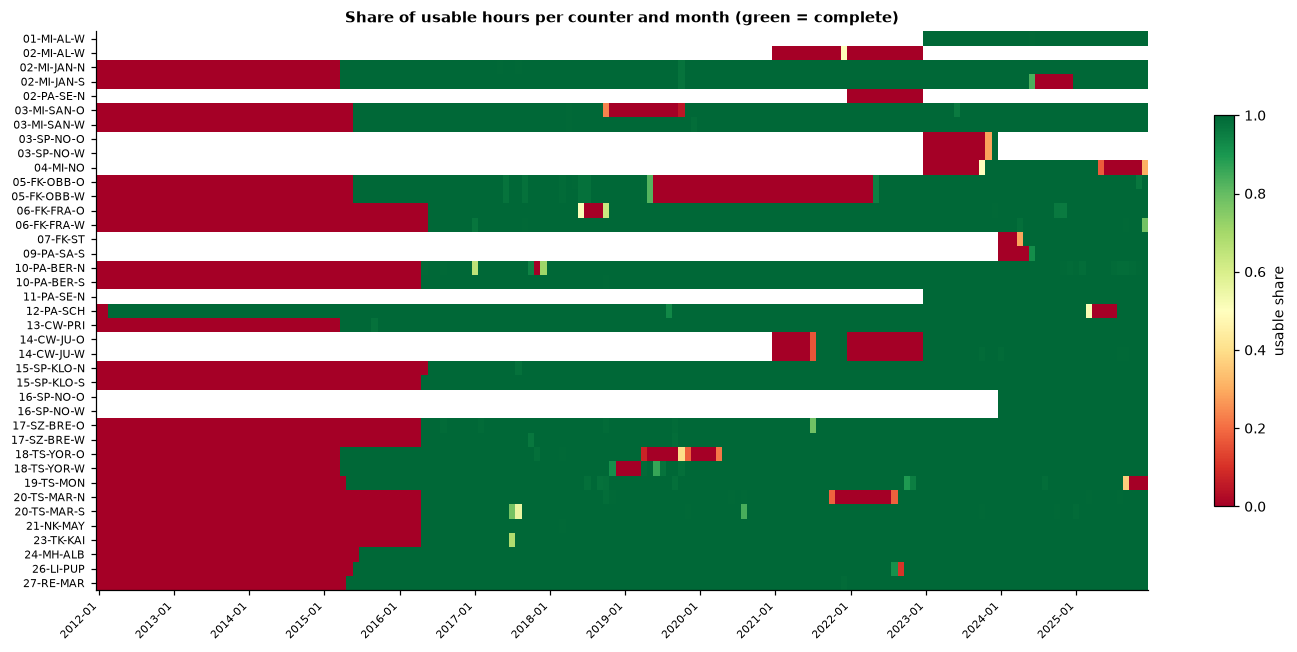

In [12]:
h = hourly.copy()
h["ym"] = h["timestamp"].dt.to_period("M")
cov = h.groupby(["station", "ym"], observed=True)["usable"].mean().unstack("ym")
cov = cov.reindex(sorted(cov.index), axis=0)

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(cov.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1,
               interpolation="nearest")
ax.set_yticks(range(len(cov.index))); ax.set_yticklabels(cov.index, fontsize=7)
ax.set_xticks(range(0, cov.shape[1], 12))
ax.set_xticklabels([str(c) for c in cov.columns[::12]], rotation=45, ha="right", fontsize=7)
ax.set_title("Share of usable hours per counter and month (green = complete)")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.7, label="usable share")
plt.show()

White and red are the story: counters start at different dates and drop out for weeks at a
time. Any "total Berlin" series must be built from a **fixed set** of counters, or it jumps
whenever a sensor comes online.

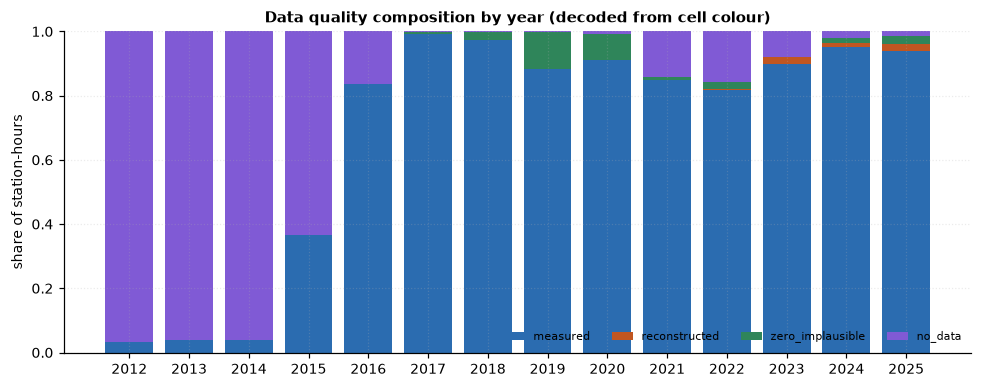

In [13]:
by_year = hourly.groupby("year")["flag"].value_counts(normalize=True).unstack().fillna(0)
order = [c for c in ["measured", "reconstructed", "zero_implausible", "no_data"]
         if c in by_year.columns]

fig, ax = plt.subplots(figsize=(9, 3.6))
bottom = np.zeros(len(by_year))
for i, col in enumerate(order):
    ax.bar(by_year.index.astype(str), by_year[col], bottom=bottom, label=col,
           color=PALETTE[i % len(PALETTE)])
    bottom += by_year[col].values
ax.set_ylim(0, 1); ax.set_ylabel("share of station-hours")
ax.legend(fontsize=7, ncol=4, frameon=False)
ax.set_title("Data quality composition by year (decoded from cell colour)")
plt.show()

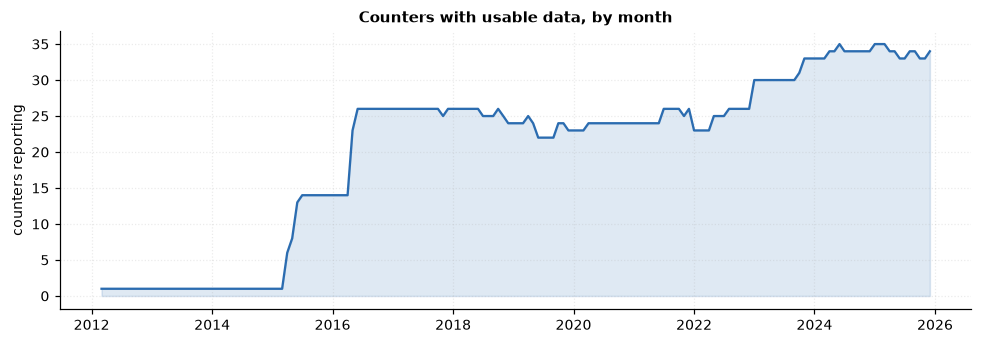

In [14]:
act = (daily.dropna(subset=["count"]).groupby(daily["date"].dt.to_period("M"))
            ["station"].nunique())

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(act.index.to_timestamp(), act.values, color=PALETTE[0])
ax.fill_between(act.index.to_timestamp(), act.values, alpha=0.15, color=PALETTE[0])
ax.set_ylabel("counters reporting")
ax.set_title("Counters with usable data, by month")
plt.show()

The network grows from one counter in 2012 to the mid-thirties, so a comparable citywide
series realistically starts in 2016–2017.

## 6. The citywide series

Built from a **balanced panel**: counters usable on at least 90% of days since 2017.

balanced panel: 22 counters


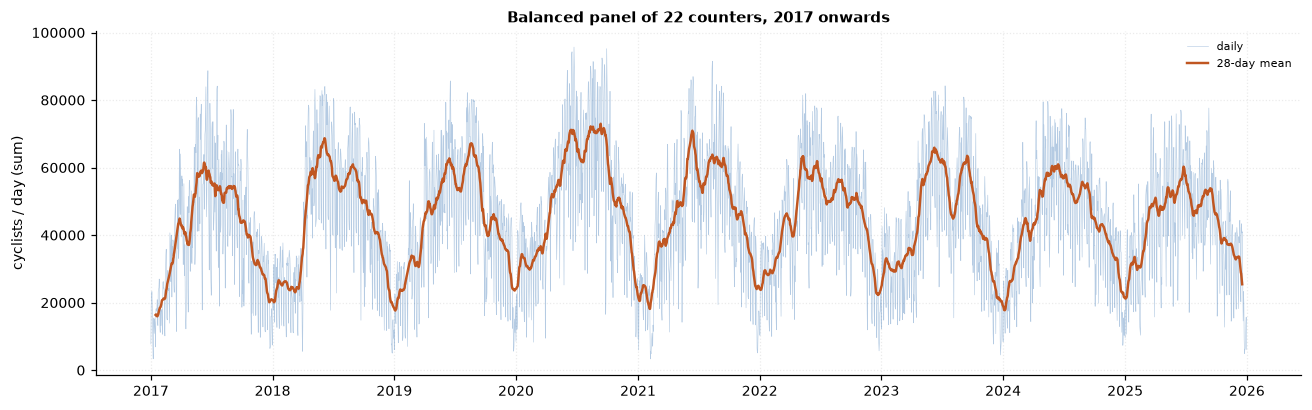

busiest day: 2020-06-23 with 95,710 crossings


In [15]:
BASE_YEAR = 2017

d = daily[daily["year"] >= BASE_YEAR].dropna(subset=["count"])
span = daily.loc[daily["year"] >= BASE_YEAR, "date"].nunique()
coverage = d.groupby("station", observed=True)["date"].nunique() / span
panel_stations = list(coverage[coverage >= 0.9].index)
panel = d[d["station"].isin(panel_stations)].groupby("date")["count"].sum()

print(f"balanced panel: {len(panel_stations)} counters")

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(panel.index, panel.values, lw=0.4, alpha=0.35, color=PALETTE[0], label="daily")
ax.plot(panel.index, panel.rolling(28, center=True).mean(), lw=1.6, color=PALETTE[1],
        label="28-day mean")
ax.set_ylabel("cyclists / day (sum)"); ax.legend(fontsize=7, frameon=False)
ax.set_title(f"Balanced panel of {len(panel_stations)} counters, {BASE_YEAR} onwards")
plt.show()

print(f"busiest day: {panel.idxmax():%Y-%m-%d} with {panel.max():,.0f} crossings")

In [16]:
p = daily[daily["station"].isin(panel_stations)].dropna(subset=["count"])
print("mean cyclists per counter per day, by year")
display(p.groupby("year")["count"].mean().round(0).to_frame("mean_daily"))

wk = p.groupby("is_weekend")["count"].mean()
print(f"weekday {wk[False]:,.0f}   weekend {wk[True]:,.0f}   "
      f"ratio {wk[True] / wk[False]:.2f}")

mean cyclists per counter per day, by year


,mean_daily
year,
2012,2018.0
2013,1760.0
2014,2074.0
2015,2562.0
2016,2101.0
2017,1853.0
2018,2049.0
2019,2047.0
2020,2332.0


weekday 2,347   weekend 1,422   ratio 0.61


2020 stands out as the busiest year on record, then volumes settle back with no clear trend.
Note this is *not* evidence of a lasting cycling boom — decide explicitly how you treat
2020–2021 before fitting any trend.

## 7. Seasonality and weekday effects

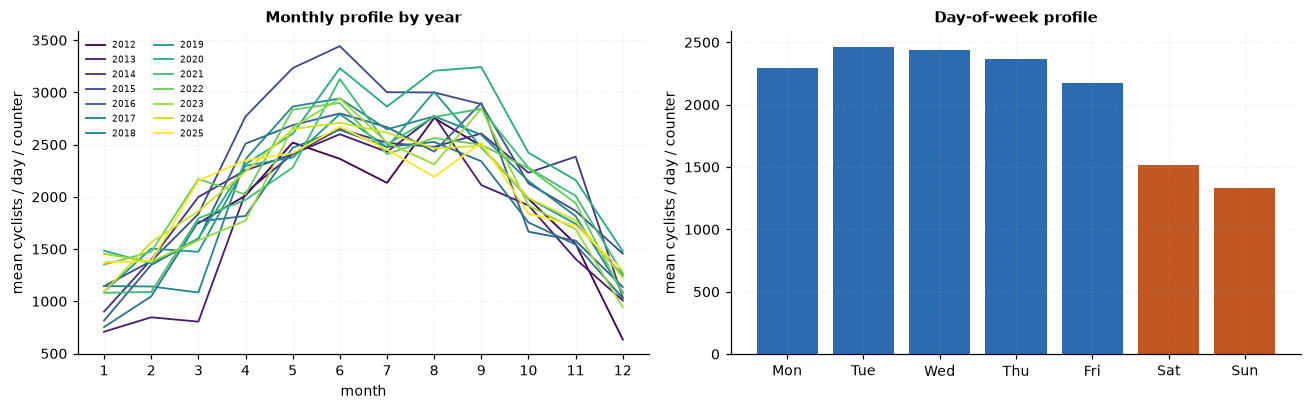

winter trough (Dec) 1,137 vs summer peak (Jun) 2,844 -> factor 2.5


In [17]:
piv = p.pivot_table(index="month", columns="year", values="count", aggfunc="mean")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for i, y in enumerate(piv.columns):
    axes[0].plot(piv.index, piv[y], label=str(y), lw=1.2,
                 color=plt.cm.viridis(i / max(len(piv.columns) - 1, 1)))
axes[0].set_xticks(range(1, 13)); axes[0].set_xlabel("month")
axes[0].set_ylabel("mean cyclists / day / counter")
axes[0].legend(fontsize=6, ncol=2, frameon=False)
axes[0].set_title("Monthly profile by year")

dow = p.groupby("dow")["count"].mean()
names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
axes[1].bar([names[i] for i in dow.index], dow.values,
            color=[PALETTE[0] if i < 5 else PALETTE[1] for i in dow.index])
axes[1].set_ylabel("mean cyclists / day / counter")
axes[1].set_title("Day-of-week profile")
plt.show()

print(f"winter trough (Dec) {piv.mean(axis=1)[12]:,.0f} vs summer peak (Jun) "
      f"{piv.mean(axis=1)[6]:,.0f} -> factor {piv.mean(axis=1)[6] / piv.mean(axis=1)[12]:.1f}")

Month explains far more variance than weekday. The aggregate weekend dip is modest because
leisure routes offset commuter routes — which is exactly why counters should be modelled
separately rather than pooled.

## 8. Hourly profiles and counter typology

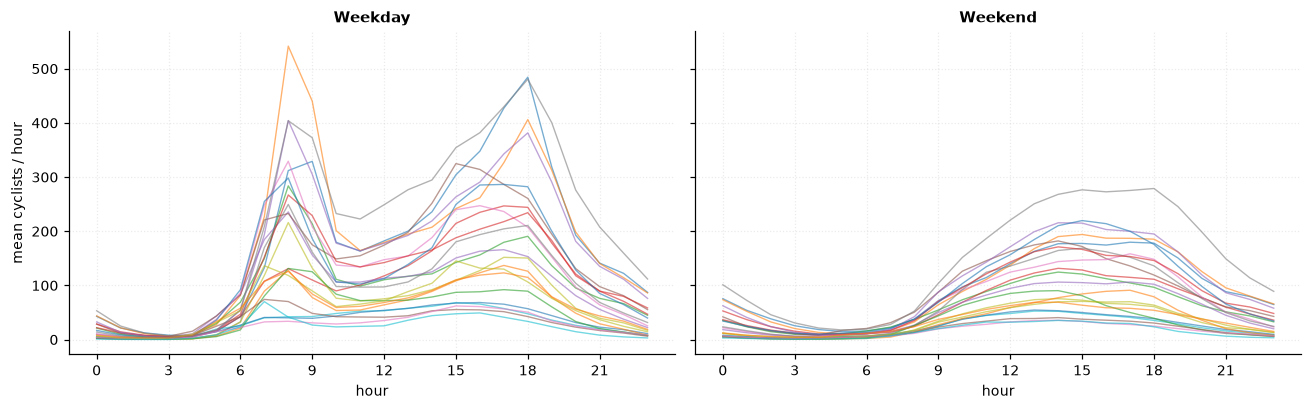

In [18]:
hh = hourly[hourly["station"].isin(panel_stations) & hourly["usable"]].copy()
hh["hour"] = hh["timestamp"].dt.hour
hh["weekend"] = hh["timestamp"].dt.dayofweek >= 5
prof = hh.groupby(["station", "weekend", "hour"], observed=True)["count"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for wknd, ax in zip([False, True], axes):
    for st, g in prof[prof["weekend"] == wknd].groupby("station", observed=True):
        ax.plot(g["hour"], g["count"], lw=0.9, alpha=0.6)
    ax.set_title("Weekend" if wknd else "Weekday")
    ax.set_xlabel("hour"); ax.set_xticks(range(0, 24, 3))
axes[0].set_ylabel("mean cyclists / hour")
plt.show()

Weekdays show twin commuting peaks around 08:00 and 17:00–18:00; weekends collapse into a
single midday hump. Cluster the *normalised* weekday shape to classify each counter, then
check the clusters against geography.

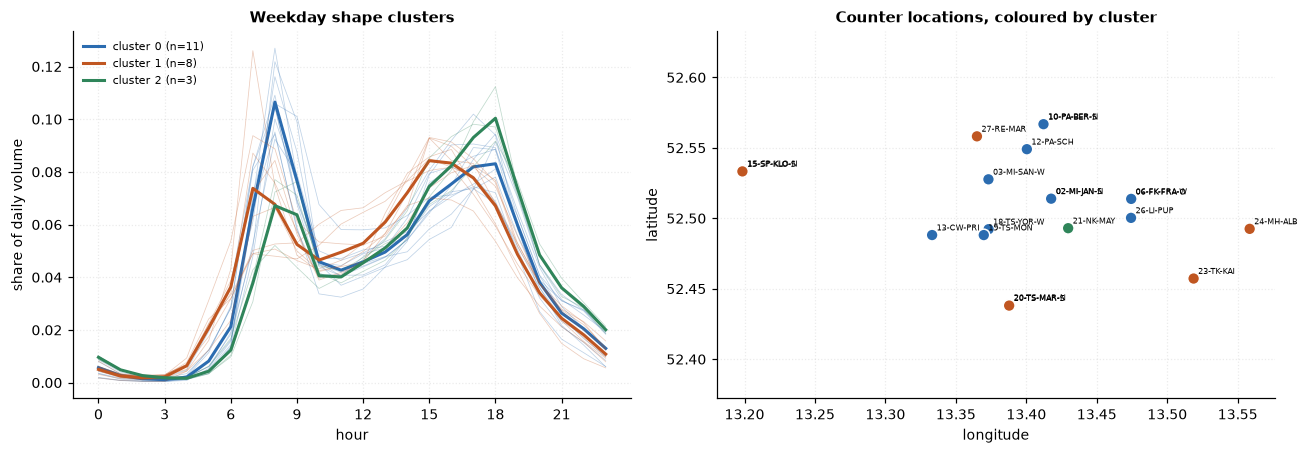

In [19]:
wd = prof[~prof["weekend"]].pivot(index="station", columns="hour", values="count").dropna()
norm = wd.div(wd.sum(axis=1), axis=0)

# Small k-means, written out to keep the notebook dependency-free.
rng = np.random.default_rng(0)
X = norm.values
K = 3
centres = X[rng.choice(len(X), K, replace=False)].copy()
for _ in range(60):
    lab = np.argmin(((X[:, None, :] - centres[None]) ** 2).sum(-1), axis=1)
    for k in range(K):
        if (lab == k).any():
            centres[k] = X[lab == k].mean(0)
labels = pd.Series(lab, index=norm.index, name="cluster")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for k in range(K):
    members = norm[labels == k]
    axes[0].plot(norm.columns, members.mean(), lw=2, color=PALETTE[k],
                 label=f"cluster {k} (n={len(members)})")
    for _, r in members.iterrows():
        axes[0].plot(norm.columns, r, lw=0.5, alpha=0.3, color=PALETTE[k])
axes[0].set_xlabel("hour"); axes[0].set_ylabel("share of daily volume")
axes[0].set_xticks(range(0, 24, 3)); axes[0].legend(fontsize=7, frameon=False)
axes[0].set_title("Weekday shape clusters")

geo = stations.set_index("station").reindex(norm.index)
axes[1].scatter(geo["lon"], geo["lat"], c=[PALETTE[k] for k in labels], s=60,
                edgecolor="white", zorder=3)
for st, r in geo.iterrows():
    axes[1].annotate(st, (r["lon"], r["lat"]), fontsize=5, xytext=(3, 3),
                     textcoords="offset points")
axes[1].set_xlabel("longitude"); axes[1].set_ylabel("latitude")
axes[1].set_title("Counter locations, coloured by cluster")
axes[1].set_aspect("equal", adjustable="datalim")
plt.show()

Three shapes fall out — sharp commuter peaks, flatter mixed traffic, and midday-heavy leisure
sites — and cluster membership lines up with geography (inner-city bridges versus canal and
park routes). That is a good sanity check, and cluster membership is a usable model feature:
the groups respond differently to weather, weekday and season.

## 9. Distributions and cross-station correlation

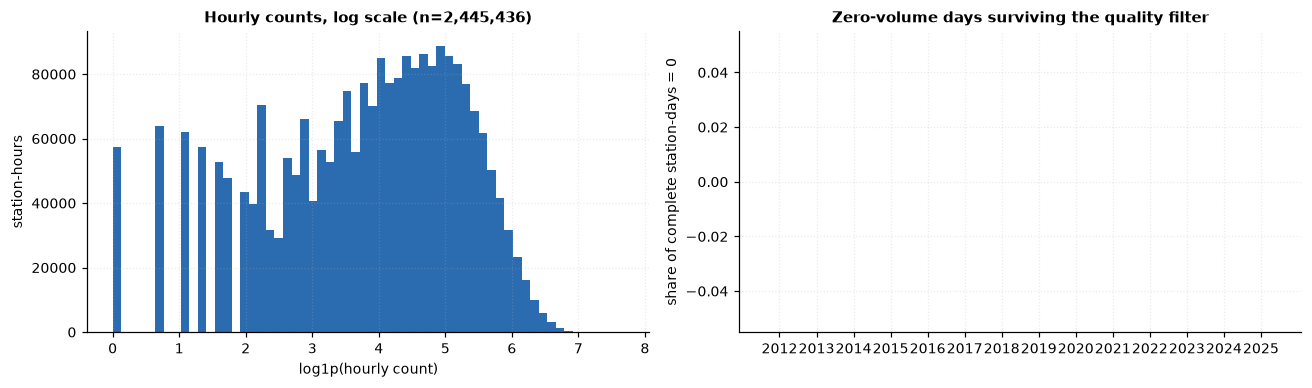

count    2445436.0
mean          94.5
std          113.8
min            0.0
25%           14.0
50%           52.0
75%          136.0
max         2167.0


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

vals = hourly.loc[hourly["usable"], "count"].dropna()
axes[0].hist(np.log1p(vals), bins=60, color=PALETTE[0])
axes[0].set_xlabel("log1p(hourly count)"); axes[0].set_ylabel("station-hours")
axes[0].set_title(f"Hourly counts, log scale (n={len(vals):,})")

zero_share = (daily.dropna(subset=["count"]).assign(z=lambda x: x["count"] == 0)
                   .groupby("year")["z"].mean())
axes[1].bar(zero_share.index.astype(str), zero_share.values, color=PALETTE[1])
axes[1].set_ylabel("share of complete station-days = 0")
axes[1].set_title("Zero-volume days surviving the quality filter")
plt.show()

print(vals.describe().round(1).to_string())

Counts are heavily right-skewed and non-negative: model them with a Poisson or Tweedie
objective, or on a log scale — not plain least squares. Surviving zero days are a residual
data-quality signal, not real behaviour.

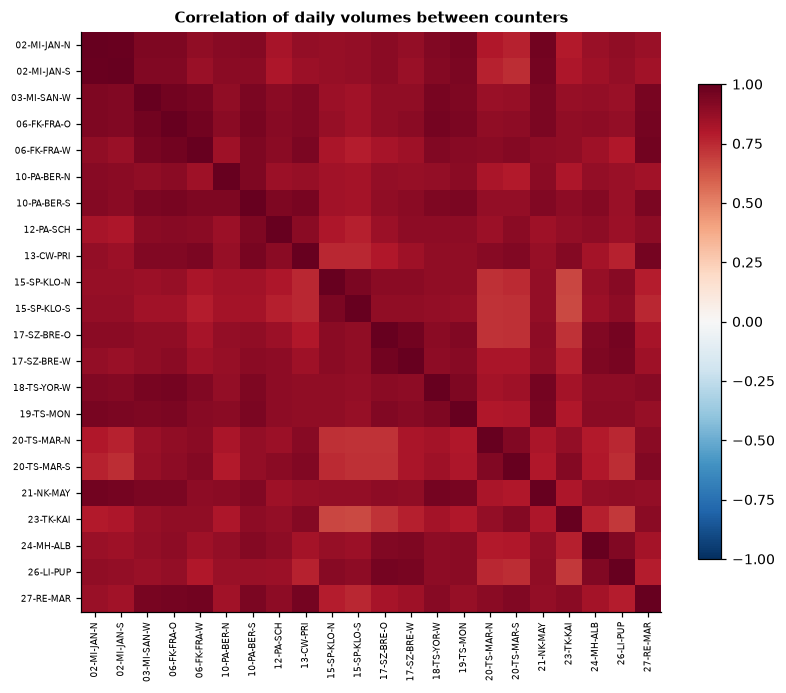

median pairwise correlation: 0.88


In [21]:
piv_daily = (daily[daily["station"].isin(panel_stations)]
             .pivot_table(index="date", columns="station", values="count"))
corr = piv_daily.corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=6)
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.75)
ax.set_title("Correlation of daily volumes between counters")
plt.show()

tri = corr.where(~np.eye(len(corr), dtype=bool))
print(f"median pairwise correlation: {tri.stack().median():.2f}")

Almost everything correlates above 0.8, because weather drives all of it simultaneously. Two
practical consequences: a single citywide weather-driven model gets you most of the way, and
one counter can be used to impute another during an outage.

## 10. The COVID years

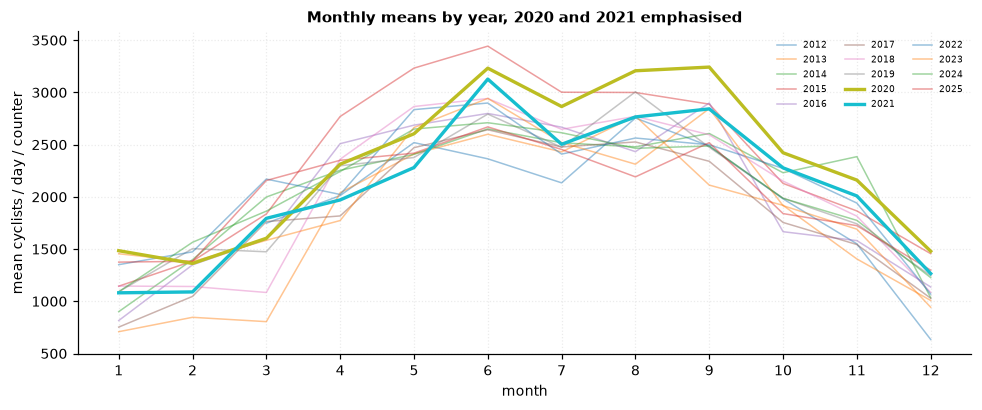

year,2019,2020,2021
month,,,
1,1091.0,1485.0,1081.0
2,1505.0,1363.0,1090.0
3,1474.0,1604.0,1795.0
4,2298.0,2313.0,1971.0
5,2377.0,2605.0,2281.0
6,2793.0,3233.0,3128.0
7,2475.0,2865.0,2504.0
8,3006.0,3208.0,2766.0
9,2475.0,3243.0,2843.0


In [22]:
m = p.groupby(["year", "month"])["count"].mean().unstack("year")

fig, ax = plt.subplots(figsize=(9, 3.8))
for y in m.columns:
    style = dict(lw=2.2, zorder=3) if y in (2020, 2021) else dict(lw=1.0, alpha=0.45)
    ax.plot(m.index, m[y], label=str(y), **style)
ax.set_xticks(range(1, 13)); ax.set_xlabel("month")
ax.set_ylabel("mean cyclists / day / counter")
ax.legend(fontsize=6, ncol=3, frameon=False)
ax.set_title("Monthly means by year, 2020 and 2021 emphasised")
plt.show()

display(m[[c for c in (2019, 2020, 2021) if c in m.columns]].round(0))

Spring 2020 breaks the pattern: lockdown suppressed commuting while leisure cycling rose.
Leaving 2020–2021 in silently will distort any trend estimate, and a random train/test split
across these years leaks the regime change into training.

## 11. Per-counter summary

In [23]:
per_station = (daily.dropna(subset=["count"]).groupby("station", observed=True)
               .agg(first_day=("date", "min"), last_day=("date", "max"),
                    usable_days=("date", "nunique"), mean_daily=("count", "mean"),
                    max_daily=("count", "max"))
               .join(stations.set_index("station")[["description", "district"]])
               .sort_values("mean_daily", ascending=False))
per_station["first_day"] = per_station["first_day"].dt.date
per_station["last_day"] = per_station["last_day"].dt.date
display(per_station.round(0))

busiest = (daily.dropna(subset=["count"]).groupby("date")["count"].sum()
           .nlargest(10).rename("total_across_counters").to_frame())
busiest["weekday"] = pd.to_datetime(busiest.index).day_name()
display(busiest.round(0))

,first_day,last_day,usable_days,mean_daily,max_daily,description,district
station,,,,,,,
05-FK-OBB-O,2015-06-01,2025-12-31,2787,5173.0,10495.0,Oberbaumbrücke Ost,FK
05-FK-OBB-W,2015-06-01,2025-12-31,2789,4905.0,10138.0,Oberbaumbrücke West,FK
21-NK-MAY,2016-05-01,2025-12-31,3532,4736.0,9270.0,Maybachufer,NK
02-MI-JAN-S,2015-04-01,2025-12-31,3737,3835.0,8948.0,Jannowitzbrücke Süd,MI
02-MI-JAN-N,2015-04-01,2025-12-31,3926,3728.0,8109.0,Jannowitzbrücke Nord,MI
09-PA-SA-S,2024-06-04,2025-12-31,576,3612.0,6624.0,Schönhauser Allee,PA
19-TS-MON,2015-05-01,2025-09-11,3777,3596.0,8586.0,Monumentenstraße,TS
07-FK-ST,2024-04-23,2025-12-31,618,3264.0,6404.0,Strausberger Platz,FK
11-PA-SE-N,2023-01-01,2025-12-31,1096,3174.0,7348.0,Senefelder Platz Nord,PA


,total_across_counters,weekday
date,,
2024-06-25,139043.0,Tuesday
2025-06-17,137432.0,Tuesday
2024-07-09,137397.0,Tuesday
2025-03-20,137360.0,Thursday
2025-06-18,137223.0,Wednesday
2025-06-03,136218.0,Tuesday
2024-05-14,136033.0,Tuesday
2025-09-09,135297.0,Tuesday
2025-04-30,135054.0,Wednesday


## 12. Export for modelling

In [24]:
hourly_out = hourly.copy()
hourly_out["station_key"] = hourly_out["station"].map(station_key)
hourly_out.drop(columns=["usable"]).to_csv(PROC / "hourly_long.csv.gz", index=False)
daily.to_csv(PROC / "daily.csv", index=False)
cov.to_csv(PROC / "coverage_monthly.csv")
stations.join(labels, on="station").to_csv(PROC / "stations.csv", index=False)
per_station.to_csv(PROC / "per_station_summary.csv")
aliases.to_csv(PROC / "code_aliases.csv", index=False)

for f in sorted(PROC.glob("*")):
    print(f"{f.name:28s} {f.stat().st_size / 1e6:7.2f} MB")

berlin_accidents_snapped_to_edges.csv   12.27 MB
berlin_bike_2018_2025.csv       7.57 MB
berlin_bike_network.graphml   216.57 MB
berlin_bike_network_projected.graphml  238.43 MB
berlin_edge_risk.csv          163.77 MB
berlin_edge_risk_scores.csv   131.02 MB
berlin_ml_risk_dataset.csv     45.73 MB
berlin_node_risk.csv            0.66 MB
berlin_osm_edge_features.csv   51.61 MB
berlin_route_risk_edges.csv   115.66 MB
berlin_spatial_edge_risk.csv  112.69 MB
code_aliases.csv                0.00 MB
coverage_monthly.csv            0.03 MB
daily.csv                       8.19 MB
hourly.pkl                     93.74 MB
hourly_long.csv.gz             12.95 MB
per_station_summary.csv         0.00 MB
stations.csv                    0.00 MB


## Findings, and what they mean for modelling

**Data quality**

- Quality is encoded in **cell fill colour**, not in a column. Roughly 2% of station-hours are
  flagged zero-or-implausible and 0.5% are provider reconstructions; read naively, both look
  like measurements.
- The `Jahresdatei 2012` sheet runs to 31.12.2013, duplicating a full year.
- Counter codes are not stable across years — use `station_key`, not the raw code.
- Availability is ~70% across all station-hours but ~95% once a counter has been installed.
  Report the second number; the first mostly reflects counters that did not exist yet.

**Behaviour**

- Season dominates: the June mean is roughly 2.4× December.
- Weekends run at about 60% of weekday volume in aggregate, but counters split into commuter,
  mixed and leisure types with very different shapes.
- Daily volumes correlate strongly across the city (median pairwise ρ > 0.8) — weather is a
  common driver.
- 2020 was the busiest year on record; volumes have since settled with no clear trend.

**Next steps**

1. Join daily weather from DWD open data (station Berlin-Tempelhof: mean and max temperature,
   precipitation, sunshine hours) plus German public holidays for Berlin
   (`holidays.Germany(subdiv="BE")`).
2. Baselines before models: seasonal-naive, then ridge, then gradient boosting with a Poisson
   objective. Split **chronologically**, and report errors per counter and per season.
3. For accident-risk work, use these counts as the **exposure denominator** — accidents per
   estimated cyclist-kilometre, not raw accident counts. Without it, a risk model simply
   rediscovers where cyclists are.